# Machine Learning Essentials | Exercise Sheet 1

This is a group work done in collaboration with Faiq, Ali, and Samira. 

---
## Task 1 — Exploring the Data

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn import model_selection

# ── Load dataset ── 
digits = load_digits()
data         = digits["data"]          # shape (1797, 64) — flattened images
images       = digits["images"]        # shape (1797, 8, 8) — 2-D pixel grids
target       = digits["target"]        # integer label 0-9 per image
target_names = digits["target_names"]

print(f"data shape  : {data.shape}")
print(f"images shape: {images.shape}")
# Each image is 8×8 pixels.  'data' is the same thing but flattened to 64 values.

data shape  : (1797, 64)
images shape: (1797, 8, 8)


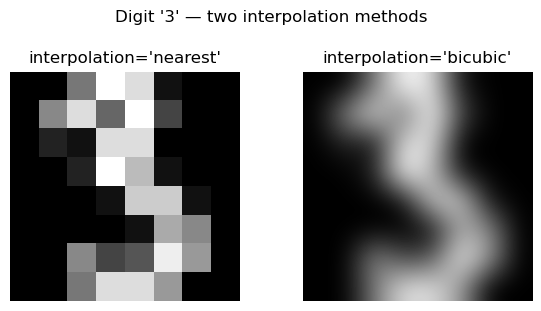

In [75]:
# ── Visualise one image of the digit '3' ──
# np.where returns indices where the condition is True; take the first hit.
idx_3 = np.where(target == 3)[0][0]
img   = images[idx_3]          # 2-D array required by imshow -> assert below
assert 2 == len(img.shape)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for ax, interp in zip(axes, ["nearest", "bicubic"]):
    ax.imshow(img, cmap="gray", interpolation=interp)
    ax.set_title(f"interpolation='{interp}'")
    ax.axis("off")
plt.suptitle("Digit '3' — two interpolation methods", y=1.02)
plt.tight_layout()
plt.show()

# 'nearest' keeps sharp pixel boundaries; 'bicubic' smooths them — the
# underlying 8×8 grid is identical for both.

In [76]:
# ── Filter to digits 3 and 9, then train/test split (ratio 3:2) ── 
mask      = (target == 3) | (target == 9)
X_all     = data[mask]      # still 64-dim feature vectors
y_raw     = target[mask]    # labels are 3 and 9

# Convert to ±1 convention required by all subsequent tasks:
#   digit 3  → label -1
#   digit 9  → label +1
y_all = np.where(y_raw == 3, -1, 1)

# test_size=0.4  →  60 % train / 40 % test  ->  ratio 3:2
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X_all, y_all, test_size=0.4, random_state=0
)

print(f"Total samples (3 & 9) : {len(X_all)}")
print(f"Training samples      : {len(X_train)}")
print(f"Test samples          : {len(X_test)}")

Total samples (3 & 9) : 363
Training samples      : 217
Test samples          : 146


---
## Task 2 — Hand-crafted Classifier

### 2.1 Feature Construction

We need to reduce 64 pixels to 2 informative features

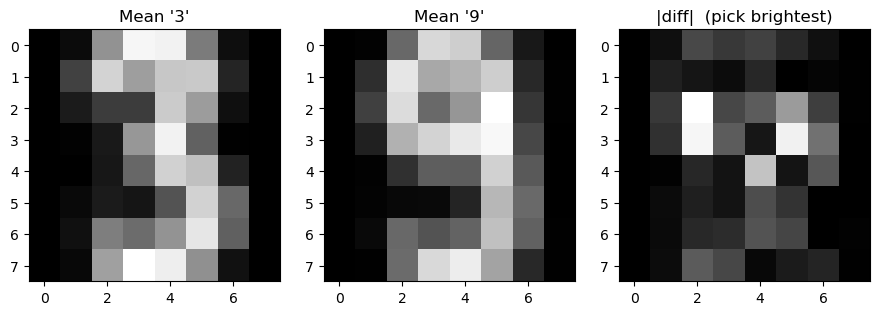

Most discriminative pixel indices: 26 and 18
(Pixel 26 is at grid position (3, 2), pixel 18 at (2, 2))


In [77]:
# ── Visualise average images for digits 3 and 9 ── 
# This helps us pick informative pixels for features.
mean_3 = X_train[y_train == -1].mean(axis=0).reshape(8, 8)
mean_9 = X_train[y_train ==  1].mean(axis=0).reshape(8, 8)
diff   = np.abs(mean_3 - mean_9)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, img_plot, title in zip(axes,
                               [mean_3, mean_9, diff],
                               ["Mean '3'", "Mean '9'", "|diff|  (pick brightest)"]):
    ax.imshow(img_plot, cmap="gray", interpolation="nearest")
    ax.set_title(title)
    ax.axis("on")
plt.tight_layout()
plt.show()

# Identify the pixel indices with highest absolute difference
flat_diff = np.abs(mean_3 - mean_9).flatten()
top2      = np.argsort(flat_diff)[-2:]    # indices of the two most different pixels
p1, p2    = int(top2[0]), int(top2[1])
print(f"Most discriminative pixel indices: {p1} and {p2}")
print(f"(Pixel {p1} is at grid position {divmod(p1,8)}, "
      f"pixel {p2} at {divmod(p2,8)})")

In [78]:
# ── features2d (mandatory interface) ── 
def features2d(x):
    """
    Map an N*64 pixel matrix to an N*2 feature matrix.

    Feature 1: pixel with the highest absolute mean-difference between classes.
    Feature 2: pixel with the second-highest absolute mean-difference.

    These two pixels were identified from the training-set mean images above.
    Choosing the pixels with the biggest inter-class difference maximises the
    margin available to a linear separator in this 2-D space.
    """
    return x[:, [p1, p2]].astype(float)

feat = features2d(X_train)
assert feat.shape == (len(X_train), 2), "features2d must return shape (N, 2)"
print("features2d output shape:", feat.shape)

features2d output shape: (217, 2)


### 2.2 Scatter Plot

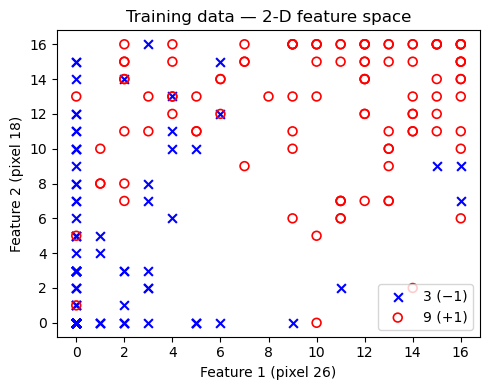

In [79]:
F_train = features2d(X_train)
F_test  = features2d(X_test)

def scatter_2class(F, y, title="", ax=None):
    # Scatter-plot a 2-D feature matrix coloured by ±1 label.
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(F[y==-1, 0], F[y==-1, 1],
               marker="x", color="blue",  s=40, label="3 (−1)")
    ax.scatter(F[y== 1, 0], F[y== 1, 1],
               marker="o", color="red",     s=40, label="9 (+1)",
               facecolors="none", linewidths=1.2)
    ax.set_xlabel(f"Feature 1 (pixel {p1})")
    ax.set_ylabel(f"Feature 2 (pixel {p2})")
    ax.set_title(title)
    ax.legend()
    return ax

scatter_2class(F_train, y_train, title="Training data — 2-D feature space")
plt.tight_layout()
plt.show()

### 2.3 Decision Rule — Nearest Mean Classifier

In [80]:
def nearest_mean(training_features, training_labels, test_features):
    
    # Nearest-mean (centroid) classifier.
    mu_neg = training_features[training_labels == -1].mean(axis=0)  # centroid of class -1
    mu_pos = training_features[training_labels ==  1].mean(axis=0)  # centroid of class +1

    # Squared Euclidean distance to each centroid for all test points
    d_neg = np.sum((test_features - mu_neg) ** 2, axis=1)
    d_pos = np.sum((test_features - mu_pos) ** 2, axis=1)

    # Predict -1 when closer to mu_neg, +1 when closer to mu_pos
    predicted = np.where(d_neg < d_pos, -1, 1)
    return predicted, mu_neg, mu_pos


def error_rate(y_true, y_pred):
    """Fraction of misclassified samples (FP + FN) / N."""
    return np.mean(y_true != y_pred)


pred_train, mu_neg, mu_pos = nearest_mean(F_train, y_train, F_train)
pred_test,  _,      _      = nearest_mean(F_train, y_train, F_test)

print(f"Nearest-mean — training error : {error_rate(y_train, pred_train):.4f}")
print(f"Nearest-mean — test error     : {error_rate(y_test,  pred_test):.4f}")

Nearest-mean — training error : 0.1106
Nearest-mean — test error     : 0.0822


### 2.4 Visualise Decision Regions

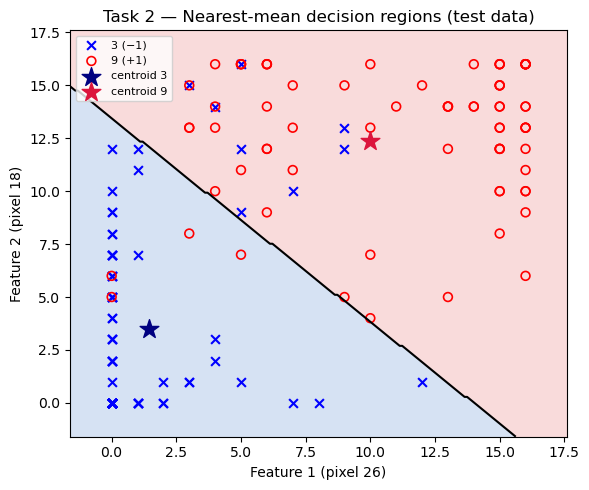

In [81]:
beta_nm = mu_pos - mu_neg                              # direction vector
b_nm    = -0.5 * (mu_pos + mu_neg) @ beta_nm           # midpoint projected onto β

def linear_predict(X, beta, b):
    return np.sign(X @ beta + b)

pred_lin_train = linear_predict(F_train, beta_nm, b_nm)
pred_lin_test  = linear_predict(F_test,  beta_nm, b_nm)

def make_grid(F, resolution=200):
    """
    Build a 2-D grid covering the feature-space extent of F
    Returns a meshgrid arrays xx, yy and the stacked (M,2) feature matrix.
    """
    pad = 0.10
    x_min, x_max = F[:, 0].min(), F[:, 0].max()
    y_min, y_max = F[:, 1].min(), F[:, 1].max()
    dx = (x_max - x_min) * pad
    dy = (y_max - y_min) * pad
    xs = np.linspace(x_min - dx, x_max + dx, resolution)
    ys = np.linspace(y_min - dy, y_max + dy, resolution)
    xx, yy = np.meshgrid(xs, ys)
    grid   = np.column_stack([xx.ravel(), yy.ravel()])
    return xx, yy, grid


def plot_decision_regions(F_ref, y_ref, predict_fn, mu_neg=None, mu_pos=None,
                          title="Decision regions", resolution=200):
    
    xx, yy, grid = make_grid(F_ref, resolution)
    Z = predict_fn(grid).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(6, 5))
    # Background: light colours for decision regions
    ax.contourf(xx, yy, Z, levels=[-2, 0, 2],
                colors=["#aec6e8", "#f5b8b8"], alpha=0.5)
    # Decision boundary
    ax.contour(xx, yy, Z, levels=[0], colors="black", linewidths=1.5)

    # Scatter test points coloured by ground-truth label
    ax.scatter(F_ref[y_ref==-1, 0], F_ref[y_ref==-1, 1],
               marker="x", color="blue", s=40, label="3 (−1)")
    ax.scatter(F_ref[y_ref== 1, 0], F_ref[y_ref== 1, 1],
               marker="o", color="red", s=40,
               facecolors="none", linewidths=1.2, label="9 (+1)")

    # Class centroids
    if mu_neg is not None:
        ax.scatter(*mu_neg, marker="*", color="navy",   s=200, zorder=5,
                   label="centroid 3")
        ax.scatter(*mu_pos, marker="*", color="crimson", s=200, zorder=5,
                   label="centroid 9")

    ax.set_xlabel(f"Feature 1 (pixel {p1})")
    ax.set_ylabel(f"Feature 2 (pixel {p2})")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()


# Nearest-mean prediction function (wraps nearest_mean to accept a grid matrix)
predict_nm = lambda X: linear_predict(X, beta_nm, b_nm)

plot_decision_regions(
    F_test, y_test,
    predict_fn=predict_nm,
    mu_neg=mu_neg, mu_pos=mu_pos,
    title="Task 2 — Nearest-mean decision regions (test data)"
)

---
## Task 3 — LDA

### 3.1 Implement LDA Training

In [ ]:
def fit_lda(training_features, training_labels):
    
    # A Linear Discriminant Analysis (LDA) model.

    X_neg = training_features[training_labels == -1]
    X_pos = training_features[training_labels ==  1]

    N     = len(training_labels)
    N_neg = len(X_neg)
    N_pos = len(X_pos)

    # Class means  (lecture formula)
    mu_neg = X_neg.mean(axis=0)       # µ-1
    mu_pos = X_pos.mean(axis=0)       # µ+1

    # Within-class scatter matrices
    dev_neg = X_neg - mu_neg          # (N-, D)  deviations from class mean
    dev_pos = X_pos - mu_pos          # (N+, D)

    # Pooled covariance: Σ-Sigma = (Σ_neg_scatter + Σ_pos_scatter) / N
    # Each scatter = Σi (Xi − µ)T (Xi − µ)  -> shape (D, D)
    S_neg  = dev_neg.T @ dev_neg      # (D, D)
    S_pos  = dev_pos.T @ dev_pos      # (D, D)
    covmat = (S_neg + S_pos) / N

    # Class priors — maximum-likelihood estimate = class frequency
    p = np.array([N_neg / N, N_pos / N])

    mu = np.vstack([mu_neg, mu_pos])  # shape (2, D)
    return mu, covmat, p


# ── Apply to 2-D features ──
mu_2d, cov_2d, p_2d = fit_lda(F_train, y_train)
print("LDA on 2-D features")
print(f"  µ-1 = {mu_2d[0]}")
print(f"  µ+1 = {mu_2d[1]}")
print(f"  Σ-Sigma   =\n{cov_2d}")
print(f"  p-Probability   = {p_2d}")

LDA on 2-D features
  µ-1 = [1.45045045 3.5045045 ]
  µ+1 = [ 9.99056604 12.38679245]
  Σ-Sigma   =
[[16.25100481  3.42470768]
 [ 3.42470768 17.84741593]]
  p-Probability   = [0.51152074 0.48847926]


In [83]:
# ── Apply to full 64-D features (with dead-pixel removal) ── 
# Dead pixels have zero variance — they carry no information and make Σ singular,
# so we mask them out before fitting.
pixel_var    = X_all.var(axis=0)              # variance of each pixel over all samples
alive_mask   = pixel_var >= 0.001             # True for informative pixels
n_alive      = alive_mask.sum()
print(f"Alive pixels (variance ≥ 0.001): {n_alive} / 64")

X_train_64 = X_train[:, alive_mask]
X_test_64  = X_test[:, alive_mask]

mu_64, cov_64, p_64 = fit_lda(X_train_64, y_train)
print(f"LDA on {n_alive}-D features: µ shape={mu_64.shape}, Σ-Sigma shape={cov_64.shape}")

Alive pixels (variance ≥ 0.001): 56 / 64
LDA on 56-D features: µ shape=(2, 56), Σ-Sigma shape=(56, 56)


### 3.2 Implement LDA Prediction

In [ ]:
def predict_lda(mu, covmat, p, test_features):

    # LDA prediction using the analytical linear decision rule

    mu_neg, mu_pos = mu[0], mu[1]

    Sigma_inv = np.linalg.pinv(covmat)                         # D×D
    beta      = Sigma_inv @ (mu_pos - mu_neg)                 # D
    b         = (-0.5 * (mu_pos + mu_neg) @ beta             # midpoint term
                 + np.log(p[1] / p[0]))                       # prior term

    scores = test_features @ beta + b
    predicted_labels = np.where(scores > 0, 1, -1)
    return predicted_labels


# ── Errors on 2-D features ── 
lda_pred_train_2d = predict_lda(mu_2d, cov_2d, p_2d, F_train)
lda_pred_test_2d  = predict_lda(mu_2d, cov_2d, p_2d, F_test)
print("LDA (2-D features)")
print(f"  Training error : {error_rate(y_train, lda_pred_train_2d):.4f}")
print(f"  Test error     : {error_rate(y_test,  lda_pred_test_2d):.4f}")

# ── Errors on 64-D features ── 
lda_pred_train_64 = predict_lda(mu_64, cov_64, p_64, X_train_64)
lda_pred_test_64  = predict_lda(mu_64, cov_64, p_64, X_test_64)
print(f"\nLDA ({n_alive}-D features)")
print(f"  Training error : {error_rate(y_train, lda_pred_train_64):.4f}")
print(f"  Test error     : {error_rate(y_test,  lda_pred_test_64):.4f}")

LDA (2-D features)
  Training error : 0.1060
  Test error     : 0.0822

LDA (56-D features)
  Training error : 0.0046
  Test error     : 0.0137


### 3.3 Visualisation — Decision Regions + Gaussian Isocontours

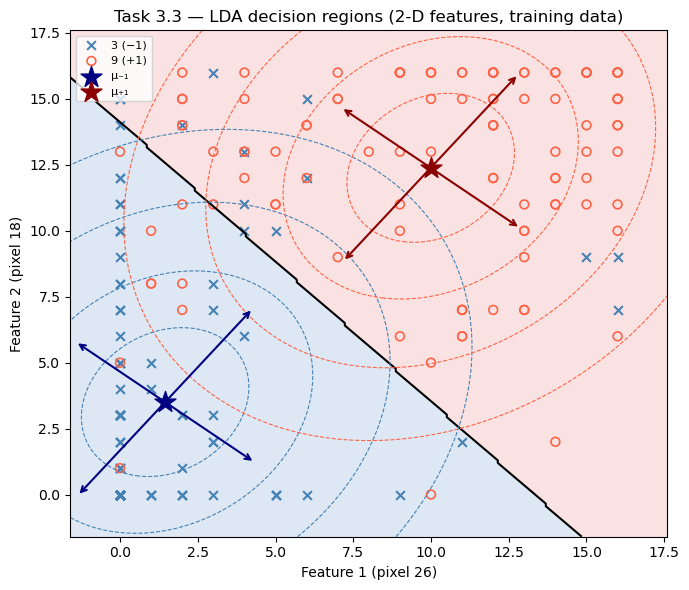

In [ ]:
from matplotlib.patches import Ellipse

def gaussian_pdf_grid(xx, yy, mean, cov):

    # Evaluate the 2-D Gaussian density on a meshgrid

    pos       = np.dstack([xx, yy])          # (H, W, 2)
    inv_cov   = np.linalg.inv(cov)
    d         = pos - mean                   # (H, W, 2)
    # Mahalanobis distance at every grid point
    maha      = np.einsum("...i,ij,...j->...", d, inv_cov, d)
    return np.exp(-0.5 * maha)


def plot_lda_2d(F_train, y_train, mu, covmat, p, title="LDA — 2D"):

    # Decision region plot for 2-D LDA.
    mu_neg, mu_pos = mu[0], mu[1]

    # Grid
    xx, yy, grid = make_grid(F_train)

    # LDA prediction on grid
    predict_fn = lambda X: predict_lda(mu, covmat, p, X)
    Z = predict_fn(grid).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(7, 6))

    # Decision regions
    ax.contourf(xx, yy, Z, levels=[-2, 0, 2],
                colors=["#aec6e8", "#f5b8b8"], alpha=0.4)
    ax.contour(xx, yy, Z, levels=[0], colors="black", linewidths=1.5)

    # Scatter training points
    ax.scatter(F_train[y_train==-1, 0], F_train[y_train==-1, 1],
               marker="x", color="steelblue", s=40, label="3 (−1)")
    ax.scatter(F_train[y_train== 1, 0], F_train[y_train== 1, 1],
               marker="o", color="tomato", s=40,
               facecolors="none", linewidths=1.2, label="9 (+1)")

    # Gaussian isocontours (levels = fraction of peak density)
    for mean, colour in [(mu_neg, "steelblue"), (mu_pos, "tomato")]:
        Z_gauss = gaussian_pdf_grid(xx, yy, mean, covmat)
        ax.contour(xx, yy, Z_gauss,
                   levels=[0.05, 0.2, 0.5, 0.8],
                   colors=colour, linestyles="dashed", linewidths=0.8)

    # Eigenvector axes (scaled by √eigenvalue = 1 Sigma along each principal axis)
    eigenvalues, eigenvectors = np.linalg.eig(covmat)
    # eigenvectors[:,i] is the i-th eigenvector (column)
    for mean, colour in [(mu_neg, "navy"), (mu_pos, "darkred")]:
        for i in range(2):
            std    = np.sqrt(np.abs(eigenvalues[i]))   # 1 Sigma along this axis
            evec   = eigenvectors[:, i] * std
            ax.annotate("",
                        xy    =(mean[0] + evec[0], mean[1] + evec[1]),
                        xytext=(mean[0] - evec[0], mean[1] - evec[1]),
                        arrowprops=dict(arrowstyle="<->", color=colour, lw=1.5))

    # Centroids
    ax.scatter(*mu_neg, marker="*", color="navy",    s=250, zorder=5, label="µ₋₁")
    ax.scatter(*mu_pos, marker="*", color="darkred", s=250, zorder=5, label="µ₊₁")

    ax.set_xlabel(f"Feature 1 (pixel {p1})")
    ax.set_ylabel(f"Feature 2 (pixel {p2})")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()


plot_lda_2d(F_train, y_train, mu_2d, cov_2d, p_2d,
            title="Task 3.3 — LDA decision regions (2-D features, training data)")

### 3.4 Quantitative Performance — 10-Fold Cross-Validation

10-fold cross-validation on full (dead-pixel-filtered) feature space
  Our LDA    — mean error: 0.0221  ±0.0272
  sklearn LDA— mean error: 0.0221  ±0.0272


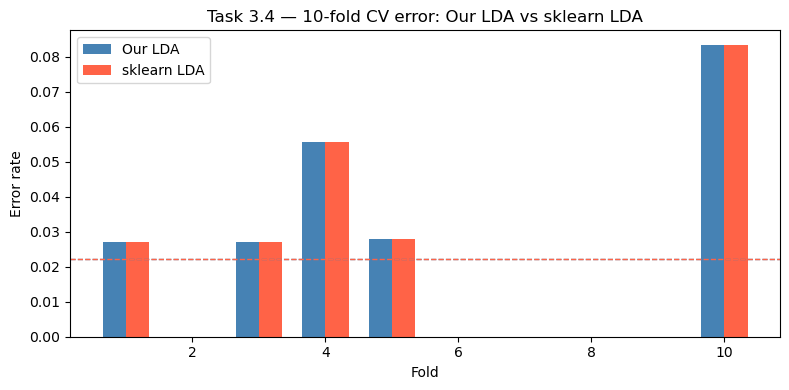

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import cross_val_score

# Use ALL available data (digits 3 & 9) for cross-validation — no prior split.
X_cv = X_all[:, alive_mask]      # filter dead pixels
y_cv = y_all                     # ±1 labels

# ── Our LDA wrapped in sklearn-compatible interface ── 
class OurLDA:

    #Thin sklearn-compatible wrapper around fit_lda / predict_lda so we can
    # plug our implementation directly into cross_val_score.
    def fit(self, X, y):
        self.mu_, self.covmat_, self.p_ = fit_lda(X, y)
        return self

    def predict(self, X):
        return predict_lda(self.mu_, self.covmat_, self.p_, X)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)   # accuracy
    
    def get_params(self, deep = True) :
        # Required for cross_val_score cloning
        return {}


cv_scores_ours = cross_val_score(OurLDA(), X_cv, y_cv, cv=10, scoring="accuracy")
cv_err_ours    = 1 - cv_scores_ours

# ── sklearn LDA for comparison ── 
sklearn_lda       = LinearDiscriminantAnalysis()
cv_scores_sklearn = cross_val_score(sklearn_lda, X_cv, y_cv, cv=10, scoring="accuracy")
cv_err_sklearn    = 1 - cv_scores_sklearn

print("10-fold cross-validation on full (dead-pixel-filtered) feature space")
print(f"  Our LDA    — mean error: {cv_err_ours.mean():.4f}  ±{cv_err_ours.std():.4f}")
print(f"  sklearn LDA— mean error: {cv_err_sklearn.mean():.4f}  ±{cv_err_sklearn.std():.4f}")

# ── Bar chart comparing fold-level errors ──
folds = np.arange(1, 11)
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(folds - width/2, cv_err_ours,    width, label="Our LDA",     color="steelblue")
ax.bar(folds + width/2, cv_err_sklearn, width, label="sklearn LDA", color="tomato")
ax.axhline(cv_err_ours.mean(),    color="steelblue", linestyle="--", linewidth=1)
ax.axhline(cv_err_sklearn.mean(), color="tomato",    linestyle="--", linewidth=1)
ax.set_xlabel("Fold")
ax.set_ylabel("Error rate")
ax.set_title("Task 3.4 — 10-fold CV error: Our LDA vs sklearn LDA")
ax.legend()
plt.tight_layout()
plt.show()

---
## Task 4 — SVM

### 4.1 Implement SVM Training (Gradient Descent)

In [ ]:
def fit_svm(training_features, training_labels,
            lam=1.0, lr=0.01, max_iter=2000, random_state=42):

    # Train a linear SVM via gradient descent on the hinge-loss objective.
    rng  = np.random.default_rng(random_state)
    N, D = training_features.shape

    beta = rng.standard_normal(D)   # Beta⁰ ~ N(0,1)
    b    = 0.0                      # b⁰ = 0

    loss_hist = []
    err_hist  = []

    # Learning-rate schedule state
    patience      = 100     # steps with no improvement before reducing lr
    min_reduction = 3       # stop after this many lr reductions
    no_improve    = 0
    reductions    = 0
    best_err      = np.inf
    tau           = lr

    for t in range(max_iter):
        # Forward pass: margin = yi*(Xi·Beta + b)
        margins    = training_labels * (training_features @ beta + b)
        violations = margins < 1          # boolean mask of hinge-active samples

        # Loss
        reg_term  = 0.5 * np.dot(beta, beta)
        data_term = (lam / N) * np.sum(np.maximum(0, 1 - margins))
        loss      = reg_term + data_term
        loss_hist.append(loss)

        # Training error
        preds = np.sign(training_features @ beta + b)
        err   = error_rate(training_labels, preds)
        err_hist.append(err)

        # Gradients
        grad_beta = (beta
                     + (lam / N)
                     * np.sum(-training_labels[violations, None]
                              * training_features[violations], axis=0))
        grad_b    = (lam / N) * np.sum(-training_labels[violations])

        # Gradient descent step
        beta -= tau * grad_beta
        b    -= tau * grad_b

        # Learning-rate schedule
        if err < best_err:
            best_err   = err
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            tau        /= 10
            no_improve  = 0
            reductions += 1
            if reductions >= min_reduction:
                break

    return beta, b, loss_hist, err_hist


def predict_svm(beta, b, test_features):
    # Linear SVM prediction: ŷ = sign(x·Beta + b).
    return np.sign(test_features @ beta + b)

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
# ── Cross-validate λ on 2-D features ──
# We try several candidate values of λ and pick the one with the lowest
# 5-fold cross-validation error on the training set.

lambda_candidates = [0.01, 0.1, 1.0, 10.0, 100.0]

class OurSVM(BaseEstimator, ClassifierMixin):
    def __init__(self, lam=1.0):
        self.lam = lam
    def fit(self, X, y):
        self.beta_, self.b_, _, _ = fit_svm(X, y, lam=self.lam)
        return self
    def predict(self, X):
        return predict_svm(self.beta_, self.b_, X)
    def score(self, X, y):
        return np.mean(self.predict(X) == y)

cv_errs_lam = {}
for lam in lambda_candidates:
    cv_scores = cross_val_score(OurSVM(lam=lam), F_train, y_train,
                                cv=5, scoring="accuracy")
    cv_errs_lam[lam] = 1 - cv_scores.mean()
    print(f"  λ={lam:6.2f}  →  CV error {cv_errs_lam[lam]:.4f}")

best_lam = min(cv_errs_lam, key=cv_errs_lam.get)
print(f"\nBest λ: {best_lam}")

  λ=  0.01  →  CV error 0.5483
  λ=  0.10  →  CV error 0.3091
  λ=  1.00  →  CV error 0.1058
  λ= 10.00  →  CV error 0.1060
  λ=100.00  →  CV error 0.1106

Best λ: 1.0


SVM (2-D features, best λ={best_lam})
  Training error : 0.1014
  Test error     : 0.0890


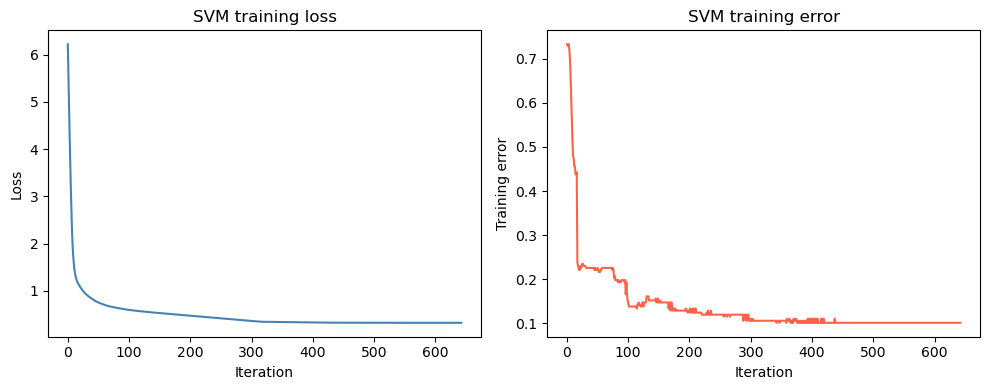

In [ ]:
# ── Train final SVM with best λ ──
beta_svm_2d, b_svm_2d, loss_hist, err_hist = fit_svm(
    F_train, y_train, lam=best_lam, lr=0.01, max_iter=3000
)

svm_pred_train_2d = predict_svm(beta_svm_2d, b_svm_2d, F_train)
svm_pred_test_2d  = predict_svm(beta_svm_2d, b_svm_2d, F_test)
print("SVM (2-D features, best λ={best_lam})")
print(f"  Training error : {error_rate(y_train, svm_pred_train_2d):.4f}")
print(f"  Test error     : {error_rate(y_test,  svm_pred_test_2d):.4f}")

# ── Plot loss + training error over iterations ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(loss_hist, color="steelblue")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Loss")
ax1.set_title("SVM training loss")

ax2.plot(err_hist, color="tomato")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Training error")
ax2.set_title("SVM training error")

plt.tight_layout()
plt.show()

### 4.2 SVM on Full Feature Space + Visualisation

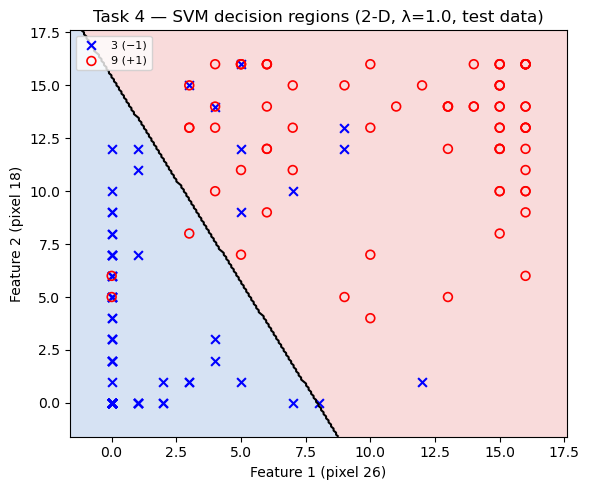

In [ ]:
# ── Decision region plot for 2-D SVM ──
predict_svm_2d = lambda X: predict_svm(beta_svm_2d, b_svm_2d, X)

plot_decision_regions(
    F_test, y_test,
    predict_fn=predict_svm_2d,
    title=f"Task 4 — SVM decision regions (2-D, λ={best_lam}, test data)"
)

In [ ]:
# ── Full 64-D SVM (dead pixels filtered) ──

# Cross-validate λ on 64-D features
cv_errs_lam_64 = {}
for lam in lambda_candidates:
    cv_scores = cross_val_score(OurSVM(lam=lam), X_train_64, y_train,
                                cv=5, scoring="accuracy")
    cv_errs_lam_64[lam] = 1 - cv_scores.mean()
    print(f"  λ={lam:6.2f}  →  CV error {cv_errs_lam_64[lam]:.4f}")

best_lam_64 = min(cv_errs_lam_64, key=cv_errs_lam_64.get)
print(f"\nBest λ (64-D): {best_lam_64}")

beta_svm_64, b_svm_64, _, _ = fit_svm(
    X_train_64, y_train, lam=best_lam_64, lr=0.001, max_iter=5000
)

svm_pred_train_64 = predict_svm(beta_svm_64, b_svm_64, X_train_64)
svm_pred_test_64  = predict_svm(beta_svm_64, b_svm_64, X_test_64)
print(f"\nSVM ({n_alive}-D)  λ={best_lam_64}")
print(f"  Training error : {error_rate(y_train, svm_pred_train_64):.4f}")
print(f"  Test error     : {error_rate(y_test,  svm_pred_test_64):.4f}")

  λ=  0.01  →  CV error 0.0093
  λ=  0.10  →  CV error 0.0093
  λ=  1.00  →  CV error 0.0230
  λ= 10.00  →  CV error 0.0185
  λ=100.00  →  CV error 0.0276

Best λ (64-D): 0.01

SVM (56-D)  λ=0.01
  Training error : 0.5530
  Test error     : 0.4932


10-fold CV on full feature space
  Our SVM      — mean error: 0.0220
  sklearn SVC  — mean error: 0.0220
  Our LDA      — mean error: 0.0221   (from Task 3.4)
  sklearn LDA  — mean error: 0.0221   (from Task 3.4)


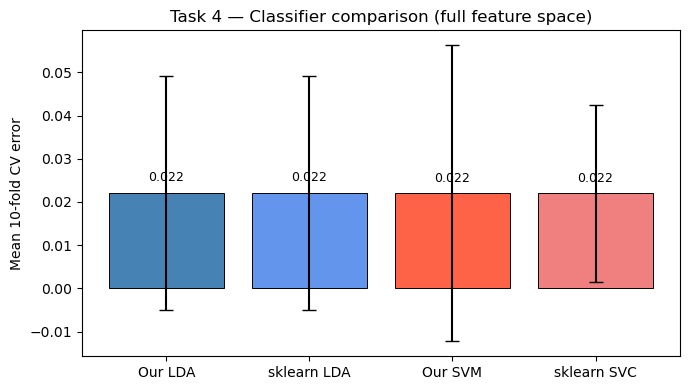

In [ ]:
# ── 10-fold CV: Our SVM vs sklearn LinearSVC ──
from sklearn.svm import LinearSVC

cv_scores_svm_ours   = cross_val_score(OurSVM(lam=best_lam_64),
                                       X_cv, y_cv, cv=10, scoring="accuracy")
cv_scores_svm_sklearn = cross_val_score(LinearSVC(max_iter=5000),
                                        X_cv, y_cv, cv=10, scoring="accuracy")

print("10-fold CV on full feature space")
print(f"  Our SVM      — mean error: {(1-cv_scores_svm_ours).mean():.4f}")
print(f"  sklearn SVC  — mean error: {(1-cv_scores_svm_sklearn).mean():.4f}")
print(f"  Our LDA      — mean error: {cv_err_ours.mean():.4f}   (from Task 3.4)")
print(f"  sklearn LDA  — mean error: {cv_err_sklearn.mean():.4f}   (from Task 3.4)")

# ── Comparison bar chart ──
methods = ["Our LDA", "sklearn LDA", "Our SVM", "sklearn SVC"]
errors  = [
    cv_err_ours.mean(),
    cv_err_sklearn.mean(),
    (1-cv_scores_svm_ours).mean(),
    (1-cv_scores_svm_sklearn).mean(),
]
stds = [
    cv_err_ours.std(),
    cv_err_sklearn.std(),
    (1-cv_scores_svm_ours).std(),
    (1-cv_scores_svm_sklearn).std(),
]
colors = ["steelblue", "cornflowerblue", "tomato", "lightcoral"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(methods, errors, color=colors, yerr=stds,
              capsize=5, edgecolor="black", linewidth=0.7)
ax.set_ylabel("Mean 10-fold CV error")
ax.set_title("Task 4 — Classifier comparison (full feature space)")
for bar, err in zip(bars, errors):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{err:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()